# Personalized Learning Path Recommendation for Interns


In [30]:

!pip install pandas numpy scikit-learn matplotlib openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error


## Load the datasets



In [17]:
interactions = pd.read_csv("intern_learning_interactions.csv")
modules = pd.read_csv("learning_modules.csv")
interns = pd.read_csv("intern_profiles.csv")

print("Interactions:", interactions.shape)
print("Modules:", modules.shape)
print("Interns:", interns.shape)

interactions.head()


Interactions: (2007, 4)
Modules: (15, 5)
Interns: (250, 4)


,intern_id,module_id,rating,completed
0,INT-0001,M02,5,0
1,INT-0001,M01,3,0
2,INT-0001,M05,4,1
3,INT-0001,M04,3,1
4,INT-0001,M10,3,1


## 4. Understand the data

### Interaction data

- `intern_id` → which intern
- `module_id` → which module
- `rating` → how much the intern liked the module, from 1 to 5
- `completed` → whether the intern completed it

### Module data

- module name
- category
- difficulty level
- duration


In [18]:
print("Interaction columns:")
print(interactions.columns.tolist())

print("\nModule information:")
print(modules)

print("\nMissing values:")
print(interactions.isnull().sum())


Interaction columns:
['intern_id', 'module_id', 'rating', 'completed']

Module information:
   module_id                  module_name          category         level  \
0        M01                Python Basics       Programming      Beginner   
1        M02     Python for Data Analysis       Programming  Intermediate   
2        M03             SQL Fundamentals          Database      Beginner   
3        M04                 Advanced SQL          Database  Intermediate   
4        M05      Machine Learning Basics  Machine Learning  Intermediate   
5        M06          Feature Engineering  Machine Learning  Intermediate   
6        M07             Model Evaluation  Machine Learning  Intermediate   
7        M08   Deep Learning Introduction                AI      Advanced   
8        M09  Natural Language Processing                AI      Advanced   
9        M10           Data Visualization              Data      Beginner   
10       M11  Statistics for Data Science              Data  

## Create the Intern × Module rating matrix


In [19]:
rating_matrix = interactions.pivot_table(
    index="intern_id",
    columns="module_id",
    values="rating",
    fill_value=0
)

print("Rating matrix shape:", rating_matrix.shape)
rating_matrix.head()


Rating matrix shape: (250, 15)


module_id,M01,M02,M03,M04,M05,M06,M07,M08,M09,M10,M11,M12,M13,M14,M15
intern_id,,,,,,,,,,,,,,,
INT-0001,3.0,5.0,0.0,3.0,4.0,0.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0
INT-0002,3.0,4.0,0.0,4.0,3.0,0.0,5.0,3.0,3.0,4.0,4.0,3.0,0.0,0.0,4.0
INT-0003,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,4.0,5.0,0.0
INT-0004,0.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,3.0,0.0,4.0
INT-0005,0.0,3.0,0.0,4.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,3.0,0.0,0.0


## Visualize the rating matrix


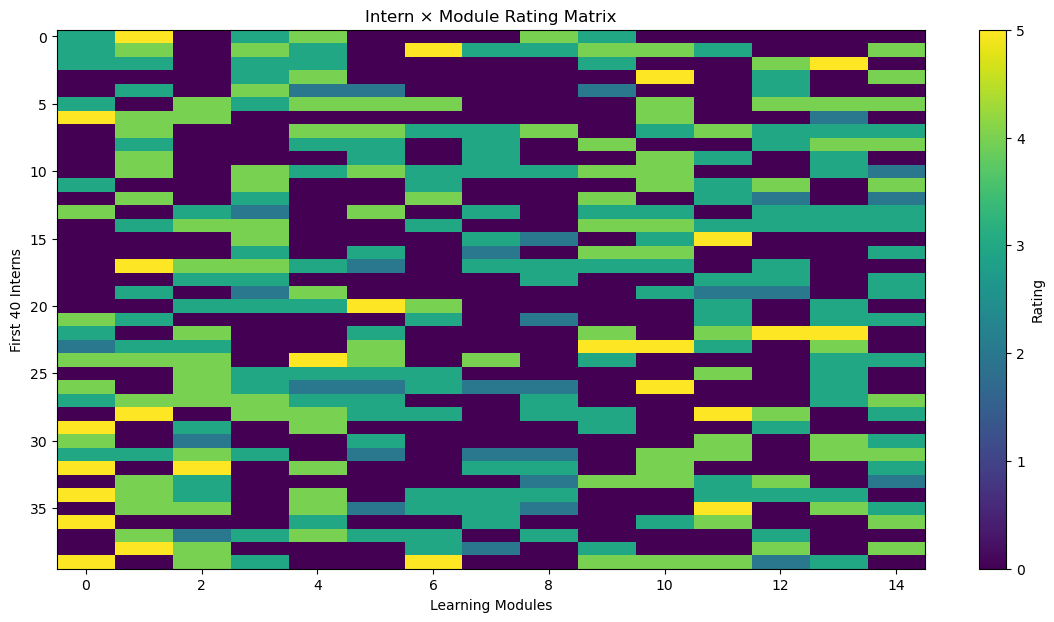

In [20]:
plt.figure(figsize=(14, 7))
plt.imshow(rating_matrix.iloc[:40], aspect="auto")
plt.xlabel("Learning Modules")
plt.ylabel("First 40 Interns")
plt.title("Intern × Module Rating Matrix")
plt.colorbar(label="Rating")
plt.show()


## Apply Matrix Factorization


In [21]:
n_components = 5

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

intern_factors = svd.fit_transform(rating_matrix)
module_factors = svd.components_

print("Intern factor matrix:", intern_factors.shape)
print("Module factor matrix:", module_factors.shape)


Intern factor matrix: (250, 5)
Module factor matrix: (5, 15)


## Reconstruct / predict ratings


In [22]:
predicted_matrix = np.dot(intern_factors, module_factors)

predicted_ratings = pd.DataFrame(
    predicted_matrix,
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

predicted_ratings.head()


module_id,M01,M02,M03,M04,M05,M06,M07,M08,M09,M10,M11,M12,M13,M14,M15
intern_id,,,,,,,,,,,,,,,
INT-0001,2.003236,3.678362,0.287399,2.049016,2.743931,1.079497,1.027650,1.430961,2.186682,-0.002965,1.605086,0.926291,0.033405,0.743921,2.805198
INT-0002,3.088233,4.377796,1.624040,3.611358,3.748439,2.895501,2.698618,2.239425,3.004665,1.516724,3.173305,1.957930,1.252973,1.646929,3.302993
INT-0003,3.408030,1.301310,1.445895,0.574529,1.701171,0.804214,0.739219,1.657531,0.859400,2.190486,1.503717,1.930424,1.782656,2.567679,1.907063
INT-0004,1.647757,1.785006,-0.300009,1.644016,2.222908,2.161471,0.955608,1.331028,1.403146,1.054880,2.478971,-0.097568,0.196520,0.634659,1.628473
INT-0005,0.122047,1.761232,1.091695,1.931917,1.149835,1.898442,1.688423,0.613167,1.193874,0.876467,1.675789,0.702298,0.577822,0.221194,0.722915


## Create a recommendation function


In [23]:
def recommend_modules(intern_id, top_n=5):
    if intern_id not in predicted_ratings.index:
        return pd.DataFrame()

    # Predicted ratings for this intern
    scores = predicted_ratings.loc[intern_id].copy()

    # Modules already studied by this intern
    already_studied = set(
        interactions.loc[
            interactions["intern_id"] == intern_id,
            "module_id"
        ]
    )

    # Do not recommend modules already studied
    scores = scores[~scores.index.isin(already_studied)]

    # Highest predicted ratings first
    recommendations = (
        scores.sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    recommendations.columns = ["module_id", "predicted_rating"]

    # Add module information
    recommendations = recommendations.merge(
        modules,
        on="module_id",
        how="left"
    )

    recommendations["predicted_rating"] = (
        recommendations["predicted_rating"]
        .clip(1, 5)
        .round(2)
    )

    return recommendations[
        [
            "module_id",
            "module_name",
            "category",
            "level",
            "duration_hours",
            "predicted_rating"
        ]
    ]


## Recommend modules for one intern


In [24]:
example_intern = "INT-0001"

recommendations = recommend_modules(
    example_intern,
    top_n=5
)

print("Recommended learning path for", example_intern)
recommendations


Recommended learning path for INT-0001


,module_id,module_name,category,level,duration_hours,predicted_rating
0,M15,Problem Solving,Professional,Intermediate,7,2.81
1,M11,Statistics for Data Science,Data,Intermediate,10,1.61
2,M08,Deep Learning Introduction,AI,Advanced,14,1.43
3,M06,Feature Engineering,Machine Learning,Intermediate,9,1.08
4,M07,Model Evaluation,Machine Learning,Intermediate,8,1.03


## Generate recommendations for many interns


In [25]:
all_recommendations = []

for intern_id in rating_matrix.index:
    recs = recommend_modules(intern_id, top_n=5)

    if not recs.empty:
        recs.insert(0, "intern_id", intern_id)
        all_recommendations.append(recs)

all_recommendations = pd.concat(
    all_recommendations,
    ignore_index=True
)

print("Total recommendations:", len(all_recommendations))
all_recommendations.head(15)


Total recommendations: 1213


,intern_id,module_id,module_name,category,level,duration_hours,predicted_rating
0,INT-0001,M15,Problem Solving,Professional,Intermediate,7,2.81
1,INT-0001,M11,Statistics for Data Science,Data,Intermediate,10,1.61
2,INT-0001,M08,Deep Learning Introduction,AI,Advanced,14,1.43
3,INT-0001,M06,Feature Engineering,Machine Learning,Intermediate,9,1.08
4,INT-0001,M07,Model Evaluation,Machine Learning,Intermediate,8,1.03
5,INT-0002,M06,Feature Engineering,Machine Learning,Intermediate,9,2.90
6,INT-0002,M14,Communication Skills,Professional,Beginner,5,1.65
7,INT-0002,M03,SQL Fundamentals,Database,Beginner,7,1.62
8,INT-0002,M13,Cloud Fundamentals,Cloud,Intermediate,9,1.25
9,INT-0003,M12,Git and GitHub,Tools,Beginner,5,1.93


## Evaluate the recommendation model



In [26]:
# Evaluate only on ratings that actually exist.
actual_values = []
predicted_values = []

for _, row in interactions.iterrows():
    intern_id = row["intern_id"]
    module_id = row["module_id"]

    actual_values.append(row["rating"])
    predicted_values.append(
        predicted_ratings.loc[intern_id, module_id]
    )

rmse = np.sqrt(
    mean_squared_error(actual_values, predicted_values)
)

print("RMSE:", round(rmse, 3))


RMSE: 1.374


## Visualize actual vs predicted ratings



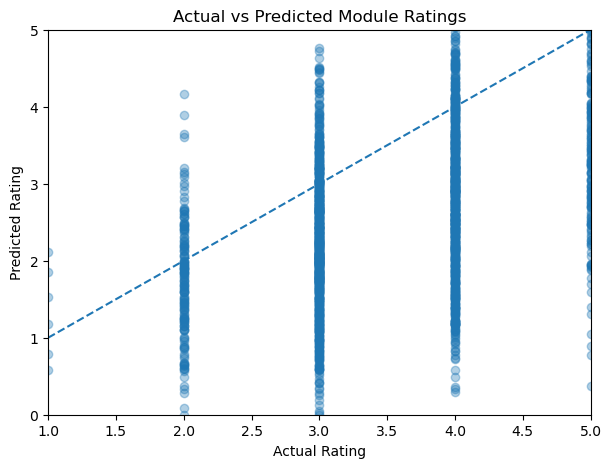

In [27]:
plt.figure(figsize=(7, 5))
plt.scatter(actual_values, predicted_values, alpha=0.35)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Module Ratings")
plt.plot([1, 5], [1, 5], linestyle="--")
plt.xlim(1, 5)
plt.ylim(0, 5)
plt.show()


## Create a personalized learning path


In [28]:
def learning_path(intern_id, top_n=5):
    recs = recommend_modules(intern_id, top_n)

    if recs.empty:
        print("Intern not found.")
        return

    print(f"Personalized Learning Path for {intern_id}")
    print("=" * 60)

    for i, row in recs.iterrows():
        print(
            f"{i+1}. {row['module_name']} "
            f"({row['level']}) - "
            f"Predicted rating: {row['predicted_rating']}/5"
        )

learning_path("INT-0001", top_n=5)


Personalized Learning Path for INT-0001
1. Problem Solving (Intermediate) - Predicted rating: 2.81/5
2. Statistics for Data Science (Intermediate) - Predicted rating: 1.61/5
3. Deep Learning Introduction (Advanced) - Predicted rating: 1.43/5
4. Feature Engineering (Intermediate) - Predicted rating: 1.08/5
5. Model Evaluation (Intermediate) - Predicted rating: 1.03/5


## 15. Save recommendations to Excel


In [29]:
all_recommendations.to_excel(
    "personalized_learning_recommendations.xlsx",
    index=False
)

print("Saved: personalized_learning_recommendations.xlsx")


Saved: personalized_learning_recommendations.xlsx
